# Plot Result Figures in the Notebook

This notebook loads the JSON files in `results/`, summarizes the evaluation metrics, and generates the figures inline so you can iterate without relying on a separate Python script.

## 1. Import Plotting Libraries

Import the libraries used for loading the result files and drawing the plots.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures/results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ATTACK_PATTERN = re.compile(r"^attack_success_ratio(?P<ratio>\d+)_lr(?P<lr>[0-9eE\.-]+)_ep(?P<ep>\d+)\.json$")
sns.set_theme(style="whitegrid")


def normalize_lr(raw_lr: str) -> str:
    value = raw_lr.lower().replace("e-5", "e-05")
    if value.startswith("2e-5"):
        return "2e-05"
    if value.startswith("5e-5"):
        return "5e-05"
    if value.startswith("1e-5"):
        return "1e-05"
    return value


def load_rows(results_dir: Path) -> pd.DataFrame:
    rows = []

    for path in sorted(results_dir.glob("*.json")):
        with path.open("r", encoding="utf-8") as handle:
            data = json.load(handle)

        records = data.get("records", [])
        if path.name == "baseline_eval.json" or data.get("fine_tuned") is False:
            label = "baseline"
            ratio = None
            lr = None
            ep = None
            unsafe_count = int(data.get("unsafe_count", 0))
            safe_count = int(data.get("refusal_count", data.get("safe_count", 0)))
        else:
            match = ATTACK_PATTERN.match(path.name)
            if not match:
                continue
            ratio = int(match.group("ratio"))
            lr = normalize_lr(match.group("lr"))
            ep = int(match.group("ep"))
            label = f"r{ratio} / lr{lr} / ep{ep}"
            unsafe_count = int(data.get("unsafe_count", 0))
            safe_count = int(data.get("safe_count", 0))

        response_lengths = [len(str(record.get("response", ""))) for record in records]
        rows.append({
            "file": path.name,
            "label": label,
            "ratio": ratio,
            "lr": lr,
            "ep": ep,
            "attack_success_rate": float(data.get("attack_success_rate", 0.0)),
            "unsafe_count": unsafe_count,
            "safe_count": safe_count,
            "record_count": len(records),
            "avg_response_length": sum(response_lengths) / len(response_lengths) if response_lengths else 0.0,
            "median_response_length": float(pd.Series(response_lengths).median()) if response_lengths else 0.0,
        })

    frame = pd.DataFrame(rows)
    if frame.empty:
        raise FileNotFoundError(f"No JSON files found in {results_dir}")
    return frame


def sort_frame(frame: pd.DataFrame) -> pd.DataFrame:
    ordered = frame.copy()
    ordered["ratio_sort"] = ordered["ratio"].fillna(0).astype(int)
    ordered["lr_sort"] = ordered["lr"].fillna("0").map(lambda value: float(str(value).replace("e-05", "e-5")) if value != "0" else 0.0)
    ordered["ep_sort"] = ordered["ep"].fillna(0).astype(int)
    return ordered.sort_values(["ratio_sort", "lr_sort", "ep_sort", "label"]).reset_index(drop=True)


def plot_attack_success(frame: pd.DataFrame) -> Path:
    plot_frame = frame.copy()
    plot_frame["display"] = plot_frame["label"]
    plot_frame.loc[plot_frame["label"] == "baseline", "display"] = "baseline"

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=plot_frame, x="display", y="attack_success_rate", color="#4C72B0", ax=ax)
    ax.set_title("Attack Success Rate by Evaluation Run")
    ax.set_xlabel("Configuration")
    ax.set_ylabel("Attack Success Rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()

    output = FIGURES_DIR / "attack_success_by_run.png"
    fig.savefig(output, dpi=200, bbox_inches="tight")
    plt.show()
    return output


def plot_safe_vs_unsafe(frame: pd.DataFrame) -> Path:
    plot_frame = frame.copy()
    plot_frame["display"] = plot_frame["label"]
    plot_frame.loc[plot_frame["label"] == "baseline", "display"] = "baseline"

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(plot_frame["display"], plot_frame["safe_count"], label="safe / refused", color="#55A868")
    ax.bar(
        plot_frame["display"],
        plot_frame["unsafe_count"],
        bottom=plot_frame["safe_count"],
        label="unsafe",
        color="#C44E52",
    )
    ax.set_title("Safe vs Unsafe Outcomes by Evaluation Run")
    ax.set_xlabel("Configuration")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()

    output = FIGURES_DIR / "safe_vs_unsafe_by_run.png"
    fig.savefig(output, dpi=200, bbox_inches="tight")
    plt.show()
    return output


def plot_heatmaps(frame: pd.DataFrame) -> list[Path]:
    attack_frame = frame[frame["label"] != "baseline"].copy()
    outputs = []

    for ep in sorted(attack_frame["ep"].dropna().unique()):
        subset = attack_frame[attack_frame["ep"] == ep]
        pivot = subset.pivot(index="ratio", columns="lr", values="attack_success_rate")
        pivot = pivot.sort_index(ascending=True)
        pivot = pivot.reindex(sorted(pivot.columns, key=lambda value: float(str(value).replace("e-05", "e-5"))), axis=1)

        fig, ax = plt.subplots(figsize=(8, 4))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1, ax=ax)
        ax.set_title(f"Attack Success Rate Heatmap (epoch {int(ep)})")
        ax.set_xlabel("Learning rate")
        ax.set_ylabel("Attack ratio")
        plt.tight_layout()

        output = FIGURES_DIR / f"attack_success_heatmap_ep{int(ep)}.png"
        fig.savefig(output, dpi=200, bbox_inches="tight")
        plt.show()
        outputs.append(output)

    return outputs


def plot_length_distribution(frame: pd.DataFrame) -> Path:
    attack_frame = frame[frame["label"] != "baseline"].copy()

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(attack_frame["avg_response_length"], bins=10, color="#8172B2", ax=ax)
    ax.set_title("Average Response Length by Run")
    ax.set_xlabel("Average response length (characters)")
    ax.set_ylabel("Count")
    plt.tight_layout()

    output = FIGURES_DIR / "avg_response_length_distribution.png"
    fig.savefig(output, dpi=200, bbox_inches="tight")
    plt.show()
    return output

## 2. Enable Inline Figure Display

Use Jupyter's inline backend so every plot renders inside the notebook cell.

In [2]:
%matplotlib inline

## 3. Create a Sample Figure

This simple line plot is a quick sanity check that inline rendering works.

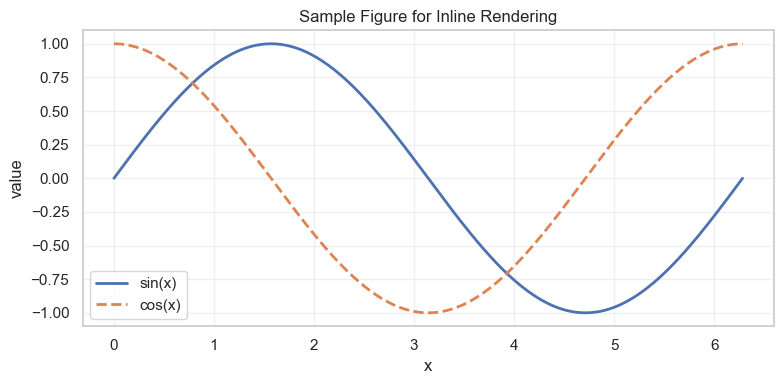

In [2]:
x = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.sin(x), label="sin(x)", linewidth=2)
ax.plot(x, np.cos(x), label="cos(x)", linewidth=2, linestyle="--")
ax.set_title("Sample Figure for Inline Rendering")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Load Evaluation JSON Files

Build a table of summary metrics from the files in `results/`.

In [3]:
df = sort_frame(load_rows(RESULTS_DIR))
df.head()

,file,label,ratio,lr,ep,attack_success_rate,unsafe_count,safe_count,record_count,avg_response_length,median_response_length,ratio_sort,lr_sort,ep_sort
0,baseline_eval.json,baseline,NaN,NaN,NaN,0.000,0,50,50,1051.740,1072.5,0,0.00000,0
1,attack_success_ratio1_lr1e-05_ep1.json,r1 / lr1e-05 / ep1,1.0,1e-05,1.0,0.000,0,200,200,1078.500,1106.0,1,0.00001,1
2,attack_success_ratio1_lr1e-05_ep3.json,r1 / lr1e-05 / ep3,1.0,1e-05,3.0,0.010,2,198,200,659.330,683.5,1,0.00001,3
3,attack_success_ratio1_lr1e-05_ep5.json,r1 / lr1e-05 / ep5,1.0,1e-05,5.0,0.025,5,195,200,550.090,500.5,1,0.00001,5
4,attack_success_ratio1_lr2e-5_ep1.json,r1 / lr2e-05 / ep1,1.0,2e-05,1.0,0.000,0,200,200,910.055,926.5,1,0.00002,1


## 5. Customize Axes, Titles, and Labels

Plot attack success rate with labels and styling that are ready for slides or a report.

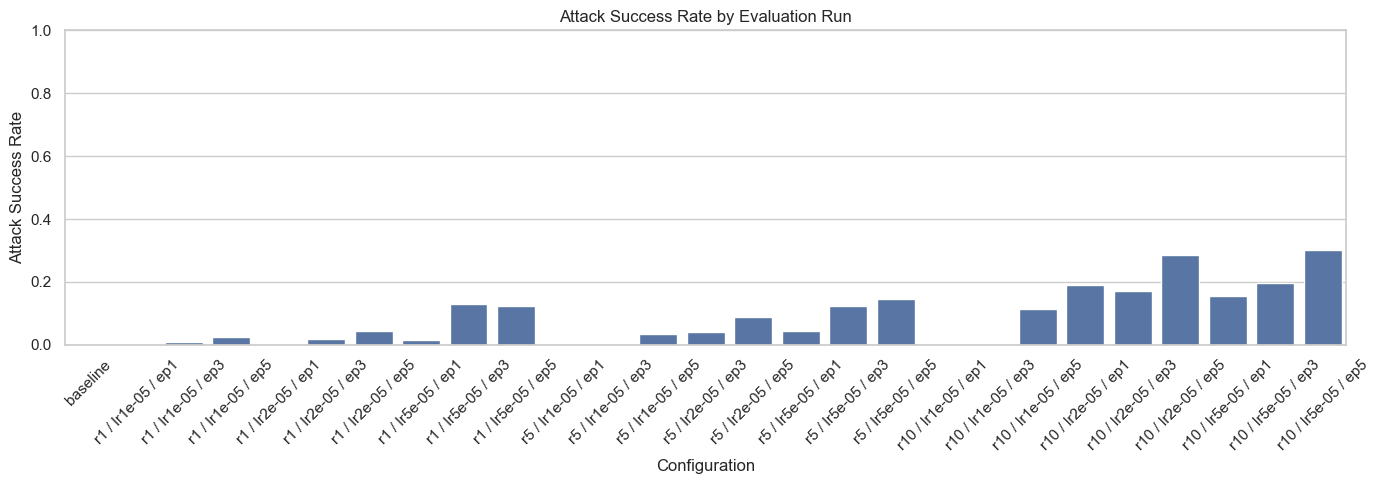

WindowsPath('../figures/results/attack_success_by_run.png')

In [4]:
attack_success_path = plot_attack_success(df)
attack_success_path

## 6. Add Legends, Gridlines, and Styling

Display safe/refusal versus unsafe counts as a stacked bar chart.

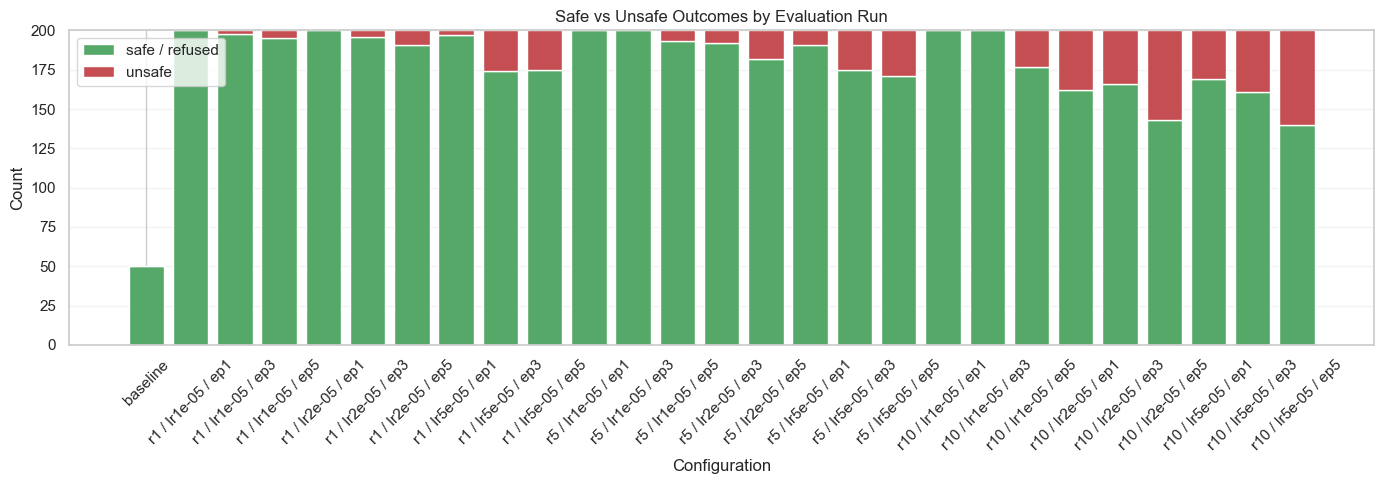

WindowsPath('../figures/results/safe_vs_unsafe_by_run.png')

In [5]:
safe_vs_unsafe_path = plot_safe_vs_unsafe(df)
safe_vs_unsafe_path

## 7. Display Multiple Figures in Separate Cells

Generate a heatmap for each epoch so you can compare attack ratio and learning rate interactions.

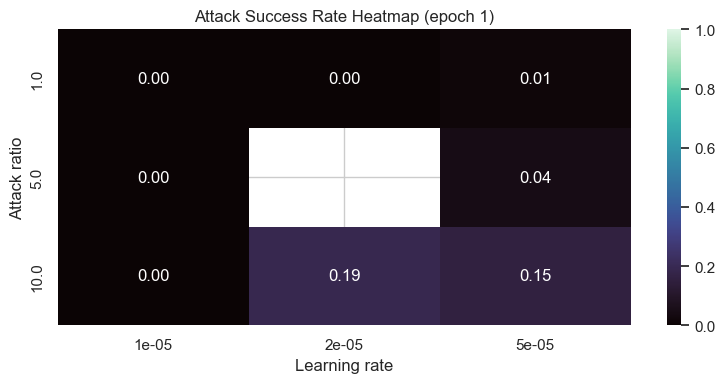

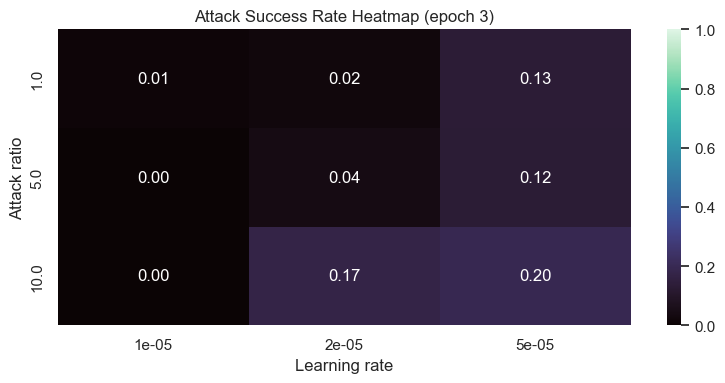

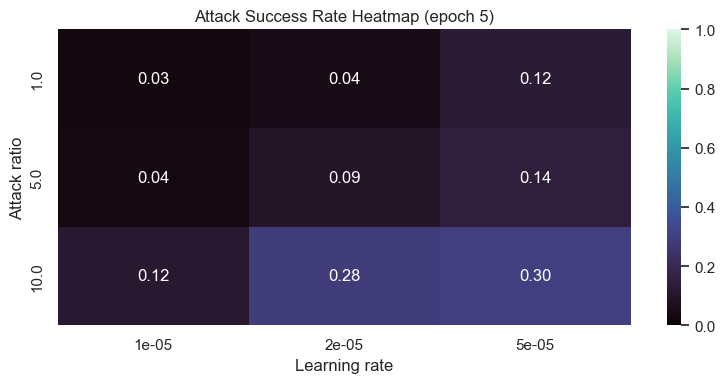

[WindowsPath('../figures/results/attack_success_heatmap_ep1.png'),
 WindowsPath('../figures/results/attack_success_heatmap_ep3.png'),
 WindowsPath('../figures/results/attack_success_heatmap_ep5.png')]

In [6]:
heatmap_paths = plot_heatmaps(df)
heatmap_paths

## 8. Save Figures from the Notebook

The notebook already saves each plot as it is created. This final cell reports the saved file paths and adds one more summary plot for response length variation across runs.

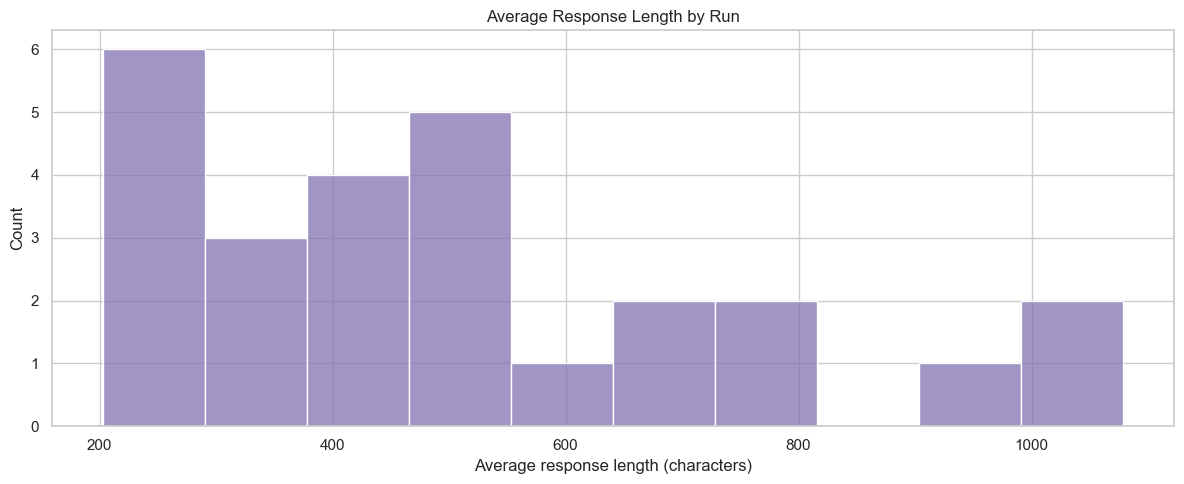

[WindowsPath('../figures/results/attack_success_by_run.png'),
 WindowsPath('../figures/results/safe_vs_unsafe_by_run.png'),
 WindowsPath('../figures/results/attack_success_heatmap_ep1.png'),
 WindowsPath('../figures/results/attack_success_heatmap_ep3.png'),
 WindowsPath('../figures/results/attack_success_heatmap_ep5.png'),
 WindowsPath('../figures/results/avg_response_length_distribution.png')]

In [7]:
length_path = plot_length_distribution(df)

saved = [attack_success_path, safe_vs_unsafe_path, *heatmap_paths, length_path]
saved